# Comparing Linear Regression Models On ___Iris DataSet___

##### Importing Initially Required Libraries

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
import numpy as np

## The OLS Algorithm

In [3]:
# OLS Method
def ols(x_train, y_train):
     x = np.matrix(x_train)
     y = np.matrix(y_train)
     b = np.linalg.inv(x.T @ x) @ x.T @ y
     return b
     
def ols_model(x_train, x_test, y_train):
     b = ols(x_train, y_train)
     y_pred = x_test @ b
     return y_pred

## The Batch Gradient Descent Algorithm

In [4]:
def batch_gd(x_train, y_train, iter = 10, n=0.01):
     x = np.matrix(x_train)
     y = np.matrix(y_train)
     b = np.matrix(np.zeros(x.shape[1]).reshape(-1, 1))
     for i in range(iter):
          y_pred = x @ b
          error = y_pred - y
          grad = (2/y.shape[0]) * x.T @ error
          b -= n * grad
     return b

def batch_gd_model(x_train, x_test, y_train, iter = 10, n=0.01):
     b = batch_gd(x_train, y_train, iter, n)
     y_pred = x_test @ b
     return y_pred

## The Main Working Program

Conversion of IRIS DataSet into a DataFrame

In [5]:
iris = load_iris()
iris_data = pd.DataFrame(columns=iris.feature_names)# type: ignore
iris_data[iris_data.columns] = iris.data# type: ignore

iris_data['target'] = iris.target#type:ignore

#### Separating Input and Output Columns
* Added a New Column of ones on the left most for intercept

In [6]:
x=iris_data.drop(columns='target')
x.insert(loc=0, column='intercept', value=1)

y=iris_data['target']

## Training Models

##### Data Splitting

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.3)

### Custom OLS Model

In [8]:
y_pred = ols_model(np.asarray(x_train), np.asarray(x_test), np.asarray(y_train).reshape(-1,1))
y_pred_ = (np.asarray(y_pred).reshape(1,y_pred.shape[0]))[0]

### Custom Batch Gradient Descent Model

In [9]:
y_pred_gd = batch_gd_model(np.asarray(x_train), np.asarray(x_test), np.asarray(y_train).reshape(-1,1), iter=10000)
y_pred__ = (np.asarray(y_pred_gd).reshape(1,y_pred.shape[0]))[0]

### Built-in Linear Regression Model

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred2=model.predict(x_test)

##### DataFrame of Outputs

In [11]:
y_dict={
     'y':y_test,
     'y_pred_':y_pred_,
     'y_pred__':y_pred__, 
     'y_pred2':y_pred2
}

out = pd.DataFrame(y_dict, columns=['y','y_pred_','y_pred__','y_pred2'])
print(out)

     y   y_pred_  y_pred__   y_pred2
40   0 -0.029373 -0.029940 -0.029373
146  2  1.714460  1.711409  1.714460
76   1  1.309031  1.310957  1.309031
104  2  1.979410  1.978545  1.979410
98   1  0.886184  0.880850  0.886184
142  2  1.716133  1.712788  1.716133
125  2  1.712419  1.716884  1.712419
67   1  0.961887  0.961936  0.961887
39   0 -0.053203 -0.052865 -0.053203
61   1  1.270902  1.269470  1.270902
17   0 -0.015026 -0.015137 -0.015026
137  2  1.657597  1.658663  1.657597
47   0 -0.037257 -0.039107 -0.037257
5    0  0.047430  0.049558  0.047430
123  2  1.609200  1.607288  1.609200
133  2  1.432072  1.432774  1.432072
106  2  1.526772  1.520420  1.526772
71   1  1.126593  1.125719  1.126593
68   1  1.406920  1.403905  1.406920
92   1  1.089216  1.087469  1.089216
12   0 -0.083443 -0.084926 -0.083443
82   1  1.061486  1.059899  1.061486
31   0  0.073326  0.073190  0.073326
113  2  1.790939  1.785789  1.790939
78   1  1.329087  1.328160  1.329087
148  2  1.939682  1.938104  1.939682
1

## Mathematical Comparison Of Models

In [12]:
from sklearn.metrics import mean_squared_error, r2_score, precision_score

print(f'My OLS model: MSE={mean_squared_error(y_test, np.asarray(y_pred_))}, r2_score={r2_score(y_test, np.asarray(y_pred_))}')
print(f'My Batch_GD model: MSE={mean_squared_error(y_test, np.asarray(y_pred__))}, r2_score={r2_score(y_test, np.asarray(y_pred__))}')
print(f'His model: MSE={mean_squared_error(y_test, np.asarray(y_pred2))}, r2_score={r2_score(y_test, np.asarray(y_pred2))}')

My OLS model: MSE=0.0635049486874439, r2_score=0.904459493988058
My Batch_GD model: MSE=0.06360757932130659, r2_score=0.9043050905455825
His model: MSE=0.06350494868744218, r2_score=0.9044594939880606


## Visual Comparison Of Models

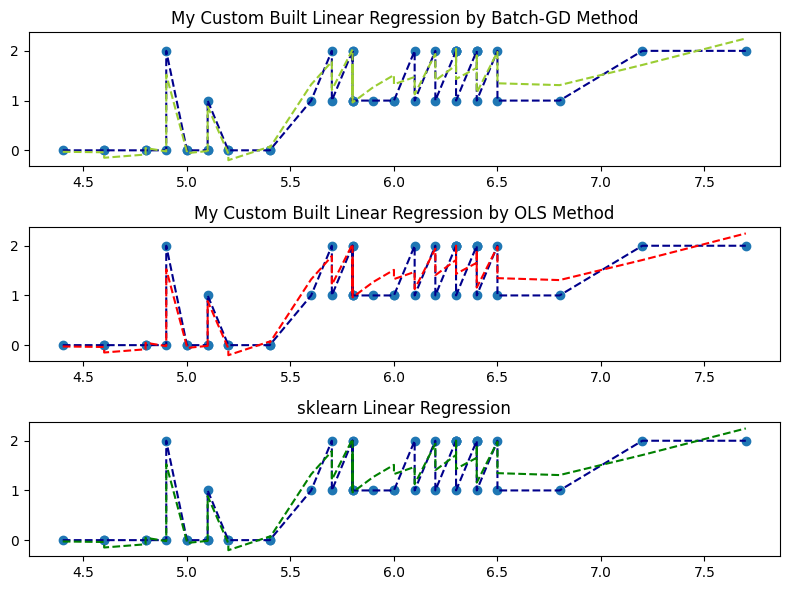

In [13]:
import matplotlib.pyplot as plt

sorted_idx = x_test['sepal length (cm)'].argsort()

fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].scatter(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx])
ax[0].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx], linestyle='--', color='darkblue')
ax[0].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_pred__[sorted_idx], color='yellowgreen', linestyle='dashed')
ax[0].set_title('My Custom Built Linear Regression by Batch-GD Method')

ax[1].scatter(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx])
ax[1].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx], linestyle='--', color='darkblue')
ax[1].plot(x_test['sepal length (cm)'].iloc[sorted_idx],y_pred_[sorted_idx] , color='red', linestyle='dashed')
ax[1].set_title('My Custom Built Linear Regression by OLS Method')

ax[2].scatter(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx])
ax[2].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_test.iloc[sorted_idx], linestyle='--', color='darkblue')
ax[2].plot(x_test['sepal length (cm)'].iloc[sorted_idx], y_pred2[sorted_idx], color='green', linestyle="dashed")
ax[2].set_title('sklearn Linear Regression')

plt.tight_layout()
plt.show()

## PairPlot Of DataSet

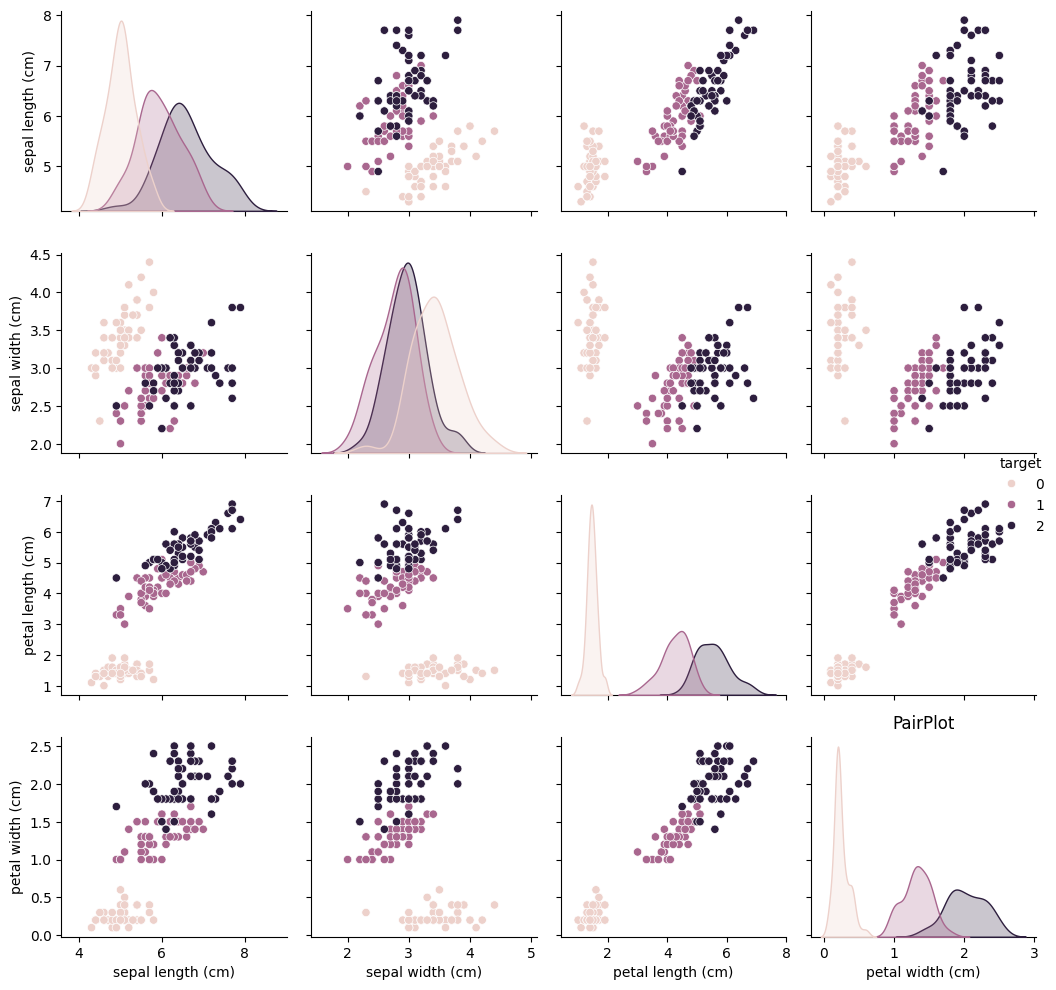

In [14]:
import seaborn as sb
sb.pairplot(data=iris_data, hue='target')
plt.title('PairPlot')
plt.tight_layout()
plt.show()